In [2]:
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import openvino as ov
from IPython.display import Markdown, display
from PIL import Image

# Fetch `notebook_utils` module
import urllib.request
urllib.request.urlretrieve(
    url='https://raw.githubusercontent.com/openvinotoolkit/openvino_notebooks/main/notebooks/utils/notebook_utils.py',
    filename='notebook_utils.py'
)
from notebook_utils import load_image

In [2]:
core = ov.Core()

model_dir = Path("model")
precision = "FP16"
detection_model = "horizontal-text-detection-0001"
recognition_model = "text-recognition-resnet-fc"

model_dir.mkdir(exist_ok=True)

In [3]:
# download_command = f"omz_downloader --name {detection_model},{recognition_model} --output_dir {model_dir} --cache_dir {model_dir} --precision {precision}  --num_attempts 5"
# display(Markdown(f"Download command: `{download_command}`"))
# display(Markdown(f"Downloading {detection_model}, {recognition_model}..."))
# !$download_command
# display(Markdown(f"Finished downloading {detection_model}, {recognition_model}."))

detection_model_path = (model_dir / "intel/horizontal-text-detection-0001" / precision / detection_model).with_suffix(".xml")
recognition_model_path = (model_dir / "public/text-recognition-resnet-fc" / precision / recognition_model).with_suffix(".xml")

In [4]:
convert_command = f"omz_converter --name {recognition_model} --precisions {precision} --download_dir {model_dir} --output_dir {model_dir}"
display(Markdown(f"Convert command: `{convert_command}`"))
display(Markdown(f"Converting {recognition_model}..."))
! $convert_command

Convert command: `omz_converter --name text-recognition-resnet-fc --precisions FP16 --download_dir model --output_dir model`

Converting text-recognition-resnet-fc...

========== Converting text-recognition-resnet-fc to ONNX
Conversion to ONNX command: c:\Users\antoi\anaconda3\envs\openvino-env\python.exe -- c:\Users\antoi\anaconda3\envs\openvino-env\lib\site-packages\openvino\model_zoo\internal_scripts\pytorch_to_onnx.py --model-path=C:\Users\antoi\anaconda3\envs\openvino-env\Lib\site-packages\openvino\model_zoo\models\public\text-recognition-resnet-fc --model-path=model\public\text-recognition-resnet-fc --model-name=get_model --import-module=model "--model-param=file_config=r\"model\public\text-recognition-resnet-fc/vedastr/configs/resnet_fc.py\"" "--model-param=weights=r\"model\public\text-recognition-resnet-fc/vedastr/ckpt/resnet_fc.pth\"" --input-shape=1,1,32,100 --input-names=input --output-names=output --output-file=model\public\text-recognition-resnet-fc/resnet_fc.onnx

ONNX check passed successfully.

========== Converting text-recognition-resnet-fc to IR (FP16)
Conversion command: c:\Users\antoi\anaconda3\envs\openvino-env\python.exe -- C:\

In [5]:
import ipywidgets as widgets

device = widgets.Dropdown(
    options=core.available_devices + ["AUTO"],
    value='AUTO',
    description='Device:',
    disabled=False,
)

device

Dropdown(description='Device:', index=3, options=('CPU', 'GPU.0', 'GPU.1', 'AUTO'), value='AUTO')

In [6]:
detection_model = core.read_model(
    model=detection_model_path, weights=detection_model_path.with_suffix(".bin")
)

detection_compiled_model = core.compile_model(model=detection_model, device_name=device.value)

detection_input_layer = detection_compiled_model.input(0)

In [7]:
recognition_model = core.read_model(
    model=recognition_model_path, weights=recognition_model_path.with_suffix(".bin")
)

recognition_compiled_model = core.compile_model(model=recognition_model, device_name=device.value)

recognition_output_layer = recognition_compiled_model.output(0)
recognition_input_layer = recognition_compiled_model.input(0)

# Get the height and width of the input layer.
_, _, H, W = recognition_input_layer.shape

In [8]:
vid = cv2.VideoCapture(r"C:\Users\antoi\Documents\CDL\Cours\Projet_Volta_Medical\test_vid.mp4")
fps = vid.get(cv2.CAP_PROP_FPS)
nbr_frame = vid.get(cv2.CAP_PROP_FRAME_COUNT)
print(f"Video has {nbr_frame} images at {fps} FPS")

Video has 5850.0 images at 29.97002997002997 FPS


In [9]:
def multiply_by_ratio(ratio_x, ratio_y, box):
    return [
        max(shape * ratio_y, 10) if idx % 2 else shape * ratio_x
        for idx, shape in enumerate(box[:-1])
    ]


def run_preprocesing_on_crop(crop, net_shape):
    temp_img = cv2.resize(crop, net_shape)
    temp_img = temp_img.reshape((1,) * 2 + temp_img.shape)
    return temp_img


def convert_result_to_image(bgr_image, resized_image, image, boxes, threshold=0.3, conf_labels=True):
    # Define colors for boxes and descriptions.
    colors = {"red": (255, 0, 0), "green": (0, 255, 0), "white": (255, 255, 255)}

    # Fetch image shapes to calculate a ratio.
    (real_y, real_x), (resized_y, resized_x) = image.shape[:2], resized_image.shape[:2]
    ratio_x, ratio_y = real_x / resized_x, real_y / resized_y

    # Convert the base image from BGR to RGB format.
    rgb_image = cv2.cvtColor(bgr_image, cv2.COLOR_BGR2RGB)

    # Iterate through non-zero boxes.
    for box, annotation in boxes:
        # Pick a confidence factor from the last place in an array.
        conf = box[-1]
        if conf > threshold:
            # Convert float to int and multiply position of each box by x and y ratio.
            (x_min, y_min, x_max, y_max) = map(int, multiply_by_ratio(ratio_x, ratio_y, box))

            # Draw a box based on the position. Parameters in the `rectangle` function are: image, start_point, end_point, color, thickness.
            cv2.rectangle(rgb_image, (x_min, y_min), (x_max, y_max), colors["green"], 3)

            # Add a text to an image based on the position and confidence. Parameters in the `putText` function are: image, text, bottomleft_corner_textfield, font, font_scale, color, thickness, line_type
            if conf_labels:
                # Create a background box based on annotation length.
                (text_w, text_h), _ = cv2.getTextSize(
                    f"{annotation}", cv2.FONT_HERSHEY_TRIPLEX, 0.8, 1
                )
                image_copy = rgb_image.copy()
                cv2.rectangle(
                    image_copy,
                    (x_min, y_min - text_h - 10),
                    (x_min + text_w, y_min - 10),
                    colors["white"],
                    -1,
                )
                # Add weighted image copy with white boxes under a text.
                cv2.addWeighted(image_copy, 0.4, rgb_image, 0.6, 0, rgb_image)
                cv2.putText(
                    rgb_image,
                    f"{annotation}",
                    (x_min, y_min - 10),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.8,
                    colors["red"],
                    1,
                    cv2.LINE_AA,
                )

    return rgb_image

In [41]:
import time
ti = time.time()

time_set = []
time_image = []
time_compilation = []

do_recognition = False

for idx in range(int(nbr_frame)) :
    # print(f"{idx+1}/{int(nbr_frame)}")
    tset = time.time()
    vid.set(cv2.CAP_PROP_POS_FRAMES, idx)
    time_set.append(time.time()-tset)
    timg = time.time()
    _, image = vid.read()
    time_image.append(time.time()-timg)

    # N,C,H,W = batch size, number of channels, height, width.
    N, C, H, W = detection_input_layer.shape

    # Resize the image to meet network expected input sizes.
    resized_image = cv2.resize(image, (W, H))

    # Reshape to the network input shape.
    input_image = np.expand_dims(resized_image.transpose(2, 0, 1), 0)

    tc = time.time()
    output_key = detection_compiled_model.output("boxes")
    boxes = detection_compiled_model([input_image])[output_key]
    time_compilation.append(time.time()-tc)

    # Remove zero only boxes.
    boxes = boxes[~np.all(boxes == 0, axis=1)]

    if do_recognition :

        _, _, H, W = recognition_input_layer.shape

        # Calculate scale for image resizing.
        (real_y, real_x), (resized_y, resized_x) = image.shape[:2], resized_image.shape[:2]
        ratio_x, ratio_y = real_x / resized_x, real_y / resized_y

        # Convert the image to grayscale for the text recognition model.
        grayscale_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

        # Get a dictionary to encode output, based on the model documentation.
        letters = "~0123456789abcdefghijklmnopqrstuvwxyz"

        # Prepare an empty list for annotations.
        annotations = list()
        cropped_images = list()
        # fig, ax = plt.subplots(len(boxes), 1, figsize=(5,15), sharex=True, sharey=True)
        # Get annotations for each crop, based on boxes given by the detection model.
        for i, crop in enumerate(boxes):
            # Get coordinates on corners of a crop.
            (x_min, y_min, x_max, y_max) = map(int, multiply_by_ratio(ratio_x, ratio_y, crop))
            image_crop = run_preprocesing_on_crop(grayscale_image[y_min:y_max, x_min:x_max], (W, H))

            # Run inference with the recognition model.
            result = recognition_compiled_model([image_crop])[recognition_output_layer]

            # Squeeze the output to remove unnecessary dimension.
            recognition_results_test = np.squeeze(result)

            # Read an annotation based on probabilities from the output layer.
            annotation = list()
            for letter in recognition_results_test:
                parsed_letter = letters[letter.argmax()]

                # Returning 0 index from `argmax` signalizes an end of a string.
                if parsed_letter == letters[0]:
                    break
                annotation.append(parsed_letter)
            annotations.append("".join(annotation))
            cropped_image = Image.fromarray(image[y_min:y_max, x_min:x_max])
            cropped_images.append(cropped_image)

        boxes_with_annotations = list(zip(boxes, annotations))

    boxes_with_annotations = list(zip(boxes, ["" for i in range(len(boxes))]))

    plt.imsave(f"C:/Users/antoi/Documents/CDL/Cours/Projet_Volta_Medical/test_rep/img_{idx:04}.png", convert_result_to_image(image, resized_image, image, boxes_with_annotations, conf_labels=True))

    if (idx+1)%100==0 :
        print(f"elapsed time : {time.time()-ti}")

print(f"elapsed time : {time.time()-ti}")

elapsed time : 31.083908557891846
elapsed time : 68.26698470115662
elapsed time : 104.8431990146637
elapsed time : 136.8352541923523
elapsed time : 175.67631459236145
elapsed time : 208.0312521457672
elapsed time : 243.7630970478058
elapsed time : 280.5202603340149
elapsed time : 313.0782995223999
elapsed time : 351.47594451904297
elapsed time : 383.33120107650757
elapsed time : 419.19586396217346
elapsed time : 456.3848123550415
elapsed time : 489.11843729019165
elapsed time : 529.3749179840088
elapsed time : 567.1705074310303
elapsed time : 609.6111822128296
elapsed time : 652.7939956188202
elapsed time : 692.2412900924683
elapsed time : 739.5365662574768
elapsed time : 779.6957170963287
elapsed time : 823.177562713623
elapsed time : 867.0726363658905
elapsed time : 907.3649806976318
elapsed time : 956.4781534671783
elapsed time : 998.4679524898529
elapsed time : 1044.8349041938782
elapsed time : 1078.6259765625
elapsed time : 1105.477546453476
elapsed time : 1138.3329663276672
elaps

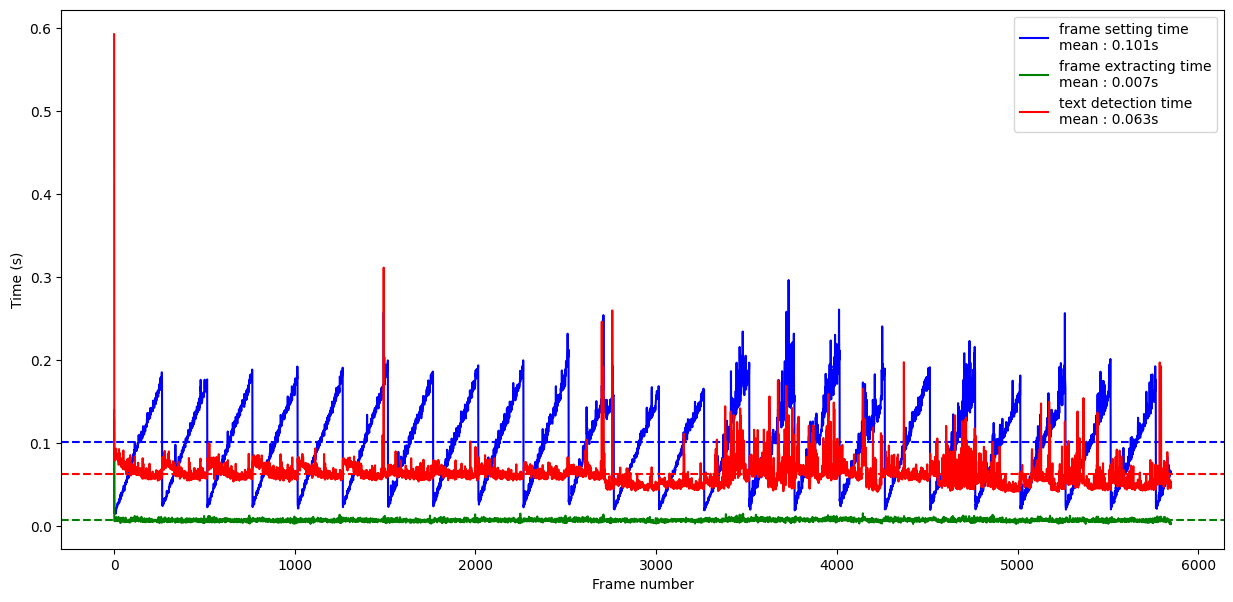

In [42]:
plt.figure(figsize=(15, 7))
plt.plot(time_set, label=f'frame setting time\nmean : {np.mean(time_set):.3f}s', c='b')
plt.axhline(np.mean(time_set), c='b', ls='--')
plt.plot(time_image, label=f'frame extracting time\nmean : {np.mean(time_image):.3f}s', c='g')
plt.axhline(np.mean(time_image), c='g', ls='--')
plt.plot(time_compilation, label=f'text detection time\nmean : {np.mean(time_compilation):.3f}s', c='r')
plt.axhline(np.mean(time_compilation), c='r', ls='--')
plt.xlabel('Frame number')
plt.ylabel('Time (s)')
plt.legend()
plt.show()

In [1]:
import glob
import os

In [70]:
imgs = glob.glob(r"C:\Users\antoi\Documents\CDL\Cours\Projet_Volta_Medical\test_rep\*.png")
imgs.sort(key=os.path.getmtime)
frame_size = cv2.imread(imgs[0]).shape[1::-1]

(1858, 682)

In [72]:
filename = 'project.avi'
fourcc = cv2.VideoWriter_fourcc(*'MJPG')
fps = 30
frame_size = cv2.imread(imgs[0]).shape[1::-1]

In [73]:
vid = cv2.VideoWriter(filename, fourcc, fps, frame_size)

In [74]:
vid.get(cv2.CAP_PROP_FRAME_HEIGHT)

0.0

In [58]:
for k, img in enumerate(imgs) :
    if k%100==0 :
        print(k)
        print(vid.get(cv2.CAP_PROP_FRAME_COUNT))
    img_arr = cv2.imread(img)
    if img_arr.shape[1::-1]=!
    vid.write(img_arr)

0
-1.0
100
-1.0


KeyboardInterrupt: 

In [12]:
vid.release()

In [13]:
help(cv2.VideoWriter)

Help on class VideoWriter in module cv2:

class VideoWriter(builtins.object)
 |  Methods defined here:
 |  
 |  __init__(self, /, *args, **kwargs)
 |      Initialize self.  See help(type(self)) for accurate signature.
 |  
 |  __repr__(self, /)
 |      Return repr(self).
 |  
 |  get(...)
 |      get(propId) -> retval
 |      .   @brief Returns the specified VideoWriter property
 |      .   
 |      .        @param propId Property identifier from cv::VideoWriterProperties (eg. cv::VIDEOWRITER_PROP_QUALITY)
 |      .        or one of @ref videoio_flags_others
 |      .   
 |      .        @return Value for the specified property. Value 0 is returned when querying a property that is
 |      .        not supported by the backend used by the VideoWriter instance.
 |  
 |  getBackendName(...)
 |      getBackendName() -> retval
 |      .   @brief Returns used backend API name
 |      .   
 |      .        @note Stream should be opened.
 |  
 |  isOpened(...)
 |      isOpened() -> retval
 |  